I'll help translate this Python script into a Jupyter notebook format with appropriate cells. Let's break it down into logical sections:



### Imports and Package Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from sklearn.model_selection import train_test_split
import precip_data_pre_processing as prep
import utils
from maxmin_exact import maxmin_exact
from NN_L2 import NN_L2
from batram.legmods import compute_scale
import batram.legmods as bat

faiss module is not installed, hence not used


/opt/anaconda3/envs/aist/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Loading and Initial Processing

In [2]:
data = prep.load_rdata("data/prec_days_101_81k_10_20.RData")
locs, precs = prep.split_data(data, d=3)
precs = np.log(precs + 1e-10)
x_loc, y_loc, z_loc, t_loc = prep.process_coordinates(locs)
Ns = 2738

### Scales Estimation

In [3]:
# # train GP on samples
# tic = time.perf_counter()
# space_scale_item, time_scale_item = utils.avg_sample_and_train_gp(locs, precs, x_loc, y_loc, z_loc, t_loc,n_epoch=100,n_samp=5)
# # scale inputs
# x_loc, y_loc, z_loc, t_loc = utils.scale_inputs(x_loc, y_loc, z_loc, t_loc, space_scale_item, time_scale_item)

x_loc, y_loc, z_loc, t_loc = utils.scale_inputs(x_loc, y_loc, z_loc, t_loc, 0.039, 0.044)

## Maximin Ordering

### Ordering and Neighbor Selection

In [4]:
locs = np.transpose(locs)
odr = maxmin_exact(locs)
locs = locs[odr, :]
precs = precs[:, odr]
m = 30
NN = NN_L2(locs, m)
NN = torch.from_numpy(NN)[:, 1:]
scal = compute_scale(locs, NN)

### Model Training Setup

In [5]:
precs_train, precs_test = train_test_split(precs, test_size=0.8, random_state=42)
precs_train, precs_test = utils.scal_mean_sd(precs_train, precs_test)
precs_train = torch.from_numpy(precs_train)
train_data = bat.Data.new(locs, precs_train.float(), NN)

thetaInit = torch.tensor([3.0781658, 2.1726654, -0.86200583, 0.9669404, 0.5366117, -1.4954433])

### Model Training

In [6]:
tm = bat.SimpleTM(train_data, thetaInit, False, smooth=1.5, nugMult=4.0)
maxIter, lr, batch_size = 50, 1e-3, 1000
tic = time.perf_counter()
res = tm.fit(maxIter, init_lr=lr, batch_size=batch_size)
print(f"fit_map used {time.perf_counter() - tic:0.4f} seconds")

Train Loss: -342525.236: 100%|██████████| 50/50 [01:44<00:00,  2.08s/it]

fit_map used 104.9959 seconds


### Sample Generation - whole sample

In [7]:
tic = time.perf_counter()
new_sample = tm.cond_sample()
print(f"draw sample used {time.perf_counter() - tic:0.4f} seconds")
print(f"estimated thetas are: {res.parameters.get('theta.theta')}")

draw sample used 30.7875 seconds
estimated thetas are: [ 1.9054658   3.3744874  -0.83286685  1.6378262   0.65855604 -1.9341794 ]


### Visualization

In [8]:
rev_ord = utils.rev_ord(odr)
new_sample = new_sample[:, rev_ord]


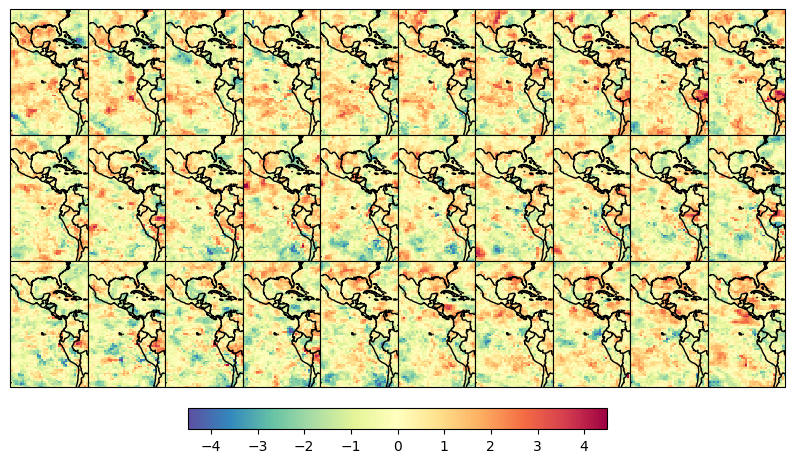

In [9]:
utils.plot_seq_heatmap(
    torch.t(torch.reshape(new_sample, (30, Ns))), FIGPATH="./", fig_name="test", suptitle="", nlat=74, nlon=37,
    numrow=3, numcol=10, vmin=-4.5, vmax=4.5, str_ints=None,
    row_labels=None, col_labels=None,
    show=True, extent=(250, 295, -29.68, 39.11), show_border=True, min_lat=-29.68, max_lat=39.11, min_lon=250,
    max_lon=295)

The heatmaps above show transformed precipitation values across spatial locations arranged in a 3x10 grid. Each subplot represents precipitation at a different time point, ordered from top left to bottom right. The color scale ranges from -4.5 (blue) to 4.5 (red) indicating transformed (log-scaled) precipitation intensity.


## Time Ordering

### Data input

In [18]:
data = prep.load_rdata("data/prec_days_101_81k_10_20.RData")
locs, precs = prep.split_data(data, d=3)
precs = np.log(precs + 1e-10)
x_loc, y_loc, z_loc, t_loc = prep.process_coordinates(locs)
Ns = 2738

### Scales Estimation

In [19]:
# # train GP on samples
# tic = time.perf_counter()
# space_scale_item, time_scale_item = utils.avg_sample_and_train_gp(locs, precs, x_loc, y_loc, z_loc, t_loc,n_epoch=100,n_samp=5)
# # scale inputs
# x_loc, y_loc, z_loc, t_loc = utils.scale_inputs(x_loc, y_loc, z_loc, t_loc, space_scale_item, time_scale_item)

x_loc, y_loc, z_loc, t_loc = utils.scale_inputs(x_loc, y_loc, z_loc, t_loc, 0.039, 0.044)


### Time Ordering and Neighbor Selection


In [20]:
locs = np.transpose(locs)
odr = utils.time_ordering(locs) # time ordering
locs = locs[odr, :]
precs = precs[:, odr]
m = 30
NN = NN_L2(locs, m)
NN = torch.from_numpy(NN)[:, 1:]
scal = compute_scale(locs, NN)

### Model Training Setup


In [21]:
precs_train, precs_test = train_test_split(precs, test_size=0.8, random_state=42)
precs_train, precs_test = utils.scal_mean_sd(precs_train, precs_test)
precs_train = torch.from_numpy(precs_train)
train_data = bat.Data.new(locs, precs_train.float(), NN)

thetaInit = torch.tensor([3.0413377,   2.1666577,  -0.9892413,   0.40906754,  0.3685641,  -1.7302552])

### Model Training

In [22]:
tm = bat.SimpleTM(train_data, thetaInit, False, smooth=1.5, nugMult=4.0)
maxIter, lr, batch_size = 50, 1e-3, 1000
tic = time.perf_counter()
res = tm.fit(maxIter, init_lr=lr, batch_size=batch_size)
print(f"fit_map used {time.perf_counter() - tic:0.4f} seconds")

Train Loss: -301083.254: 100%|██████████| 50/50 [01:46<00:00,  2.14s/it]

fit_map used 107.7235 seconds


### Conditional Sample Generation

In [23]:
partial_field = precs_test[0, :(int(Ns) * 10)]
partial_field = torch.from_numpy(partial_field).float().squeeze()
new_sample = tm.cond_sample(xFix=partial_field) # conditional sampling for time ordering



### Visualization

In [16]:
rev_ord = utils.rev_ord(odr)
new_sample = new_sample[:, rev_ord]

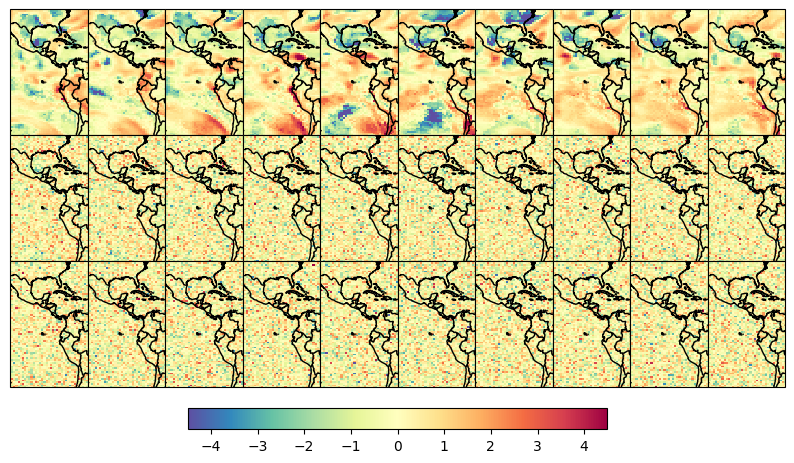

In [17]:
utils.plot_seq_heatmap(
    torch.t(torch.reshape(new_sample, (30, Ns))), FIGPATH="./", fig_name="test", suptitle="", nlat=74, nlon=37,
    numrow=3, numcol=10, vmin=-4.5, vmax=4.5, str_ints=None,
    row_labels=None, col_labels=None,
    show=True, extent=(250, 295, -29.68, 39.11), show_border=True, min_lat=-29.68, max_lat=39.11, min_lon=250,
    max_lon=295)
